In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import confusion_matrix , classification_report,roc_auc_score,roc_curve,precision_recall_curve,precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split ,GridSearchCV ,StratifiedKFold , cross_val_predict

df= load_wine( as_frame = True ).frame
df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.920,3.22,1195.0,0
168,13.58,2.58,2.69,24.5,105.0,1.55,0.84,0.39,1.54,8.66,0.740,1.80,750.0,2
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.550,1.62,650.0,2
70,12.29,1.61,2.21,20.4,103.0,1.10,1.02,0.37,1.46,3.05,0.906,1.82,870.0,1
152,13.11,1.90,2.75,25.5,116.0,2.20,1.28,0.26,1.56,7.10,0.610,1.33,425.0,2


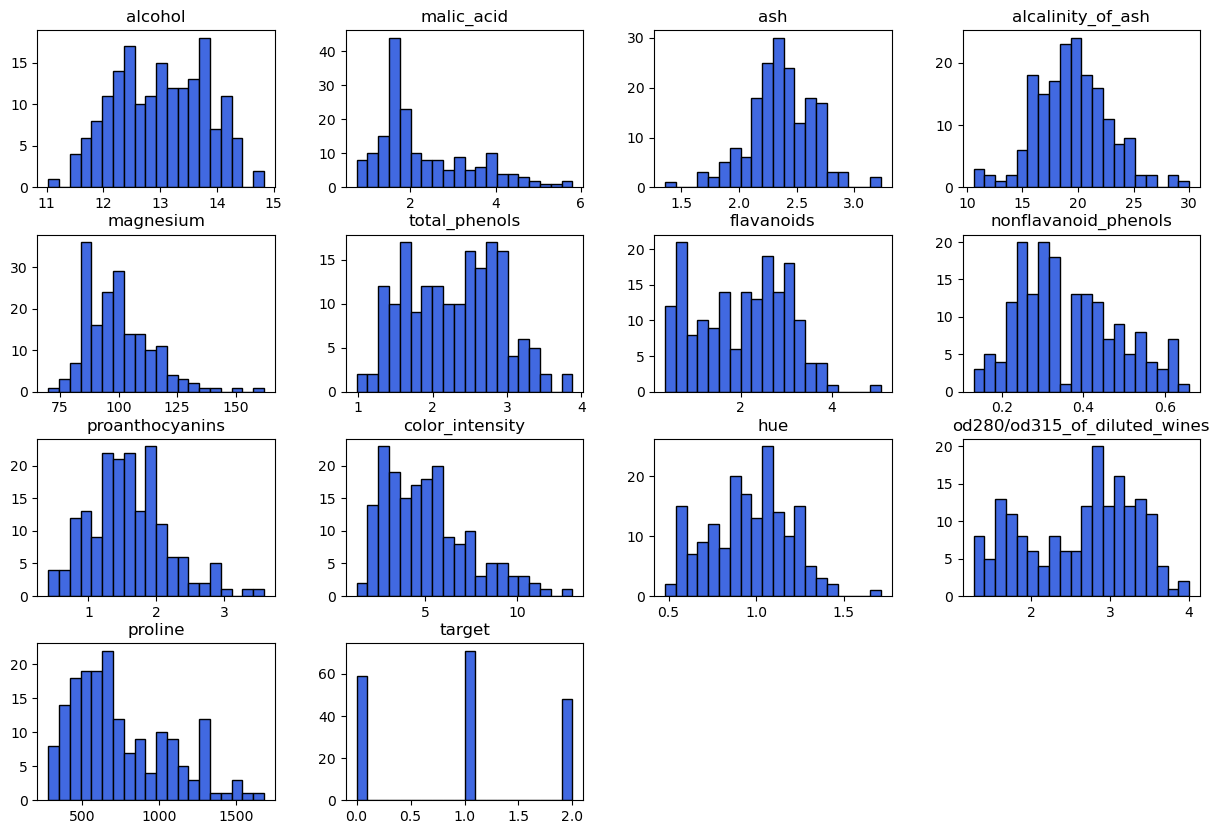

In [2]:
df.hist( figsize = (15,10), grid = False , bins = 20 , color ='royalblue' , edgecolor = 'black')
plt.show()

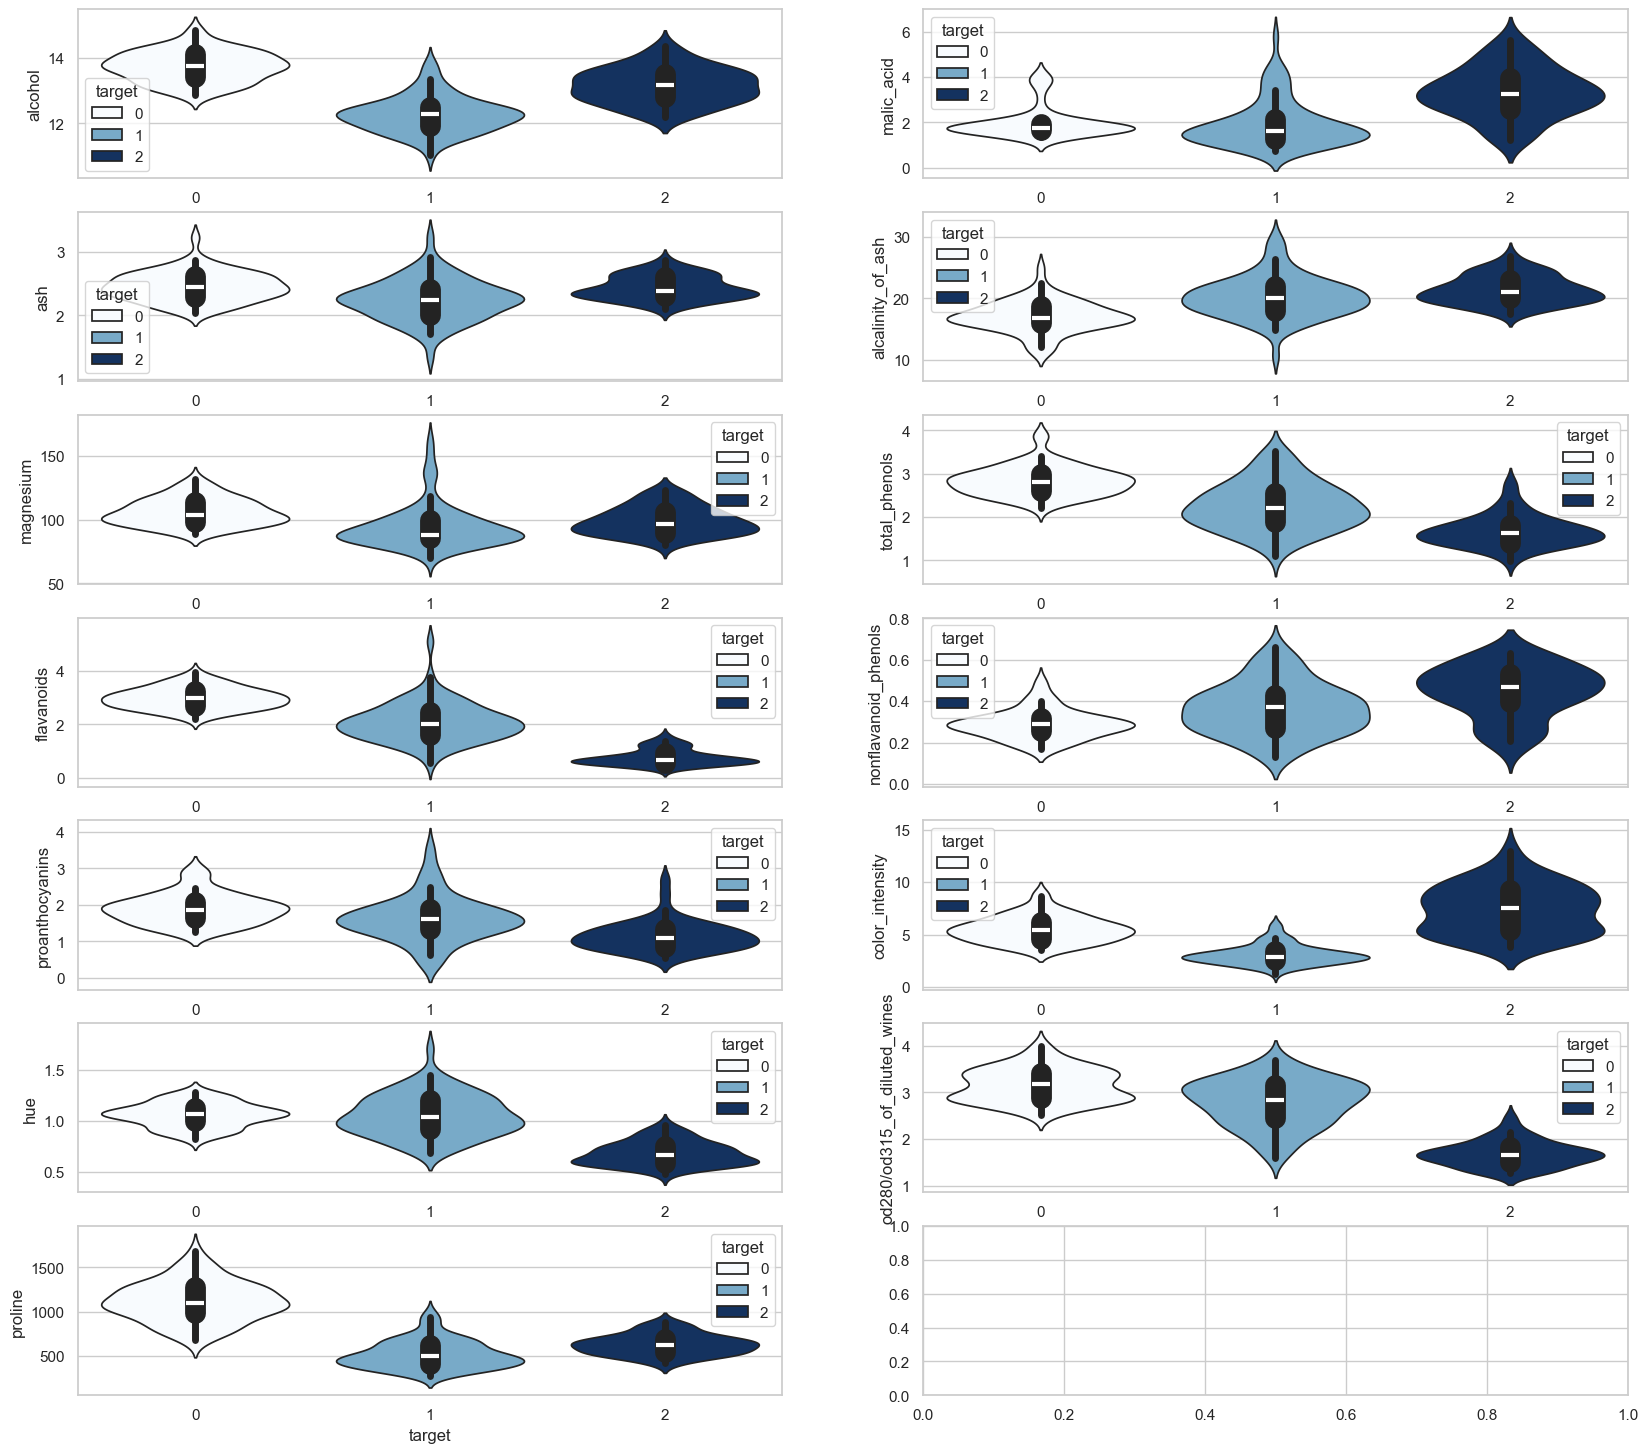

In [3]:
cols = df.drop(columns ='target').columns 
sns.set_theme(style="whitegrid", font="sans-serif")
fig , ax = plt.subplots( 7,2, figsize = ( 20, 18 ) )
ax= ax.flatten()
for idx , val in enumerate(cols ):
    sns.violinplot(data = df , y = val ,x  = 'target', hue = 'target',
                   palette = 'Blues' , ax = ax[idx] , inner_kws = {'box_width' : 15 }
                  )

plt.show()


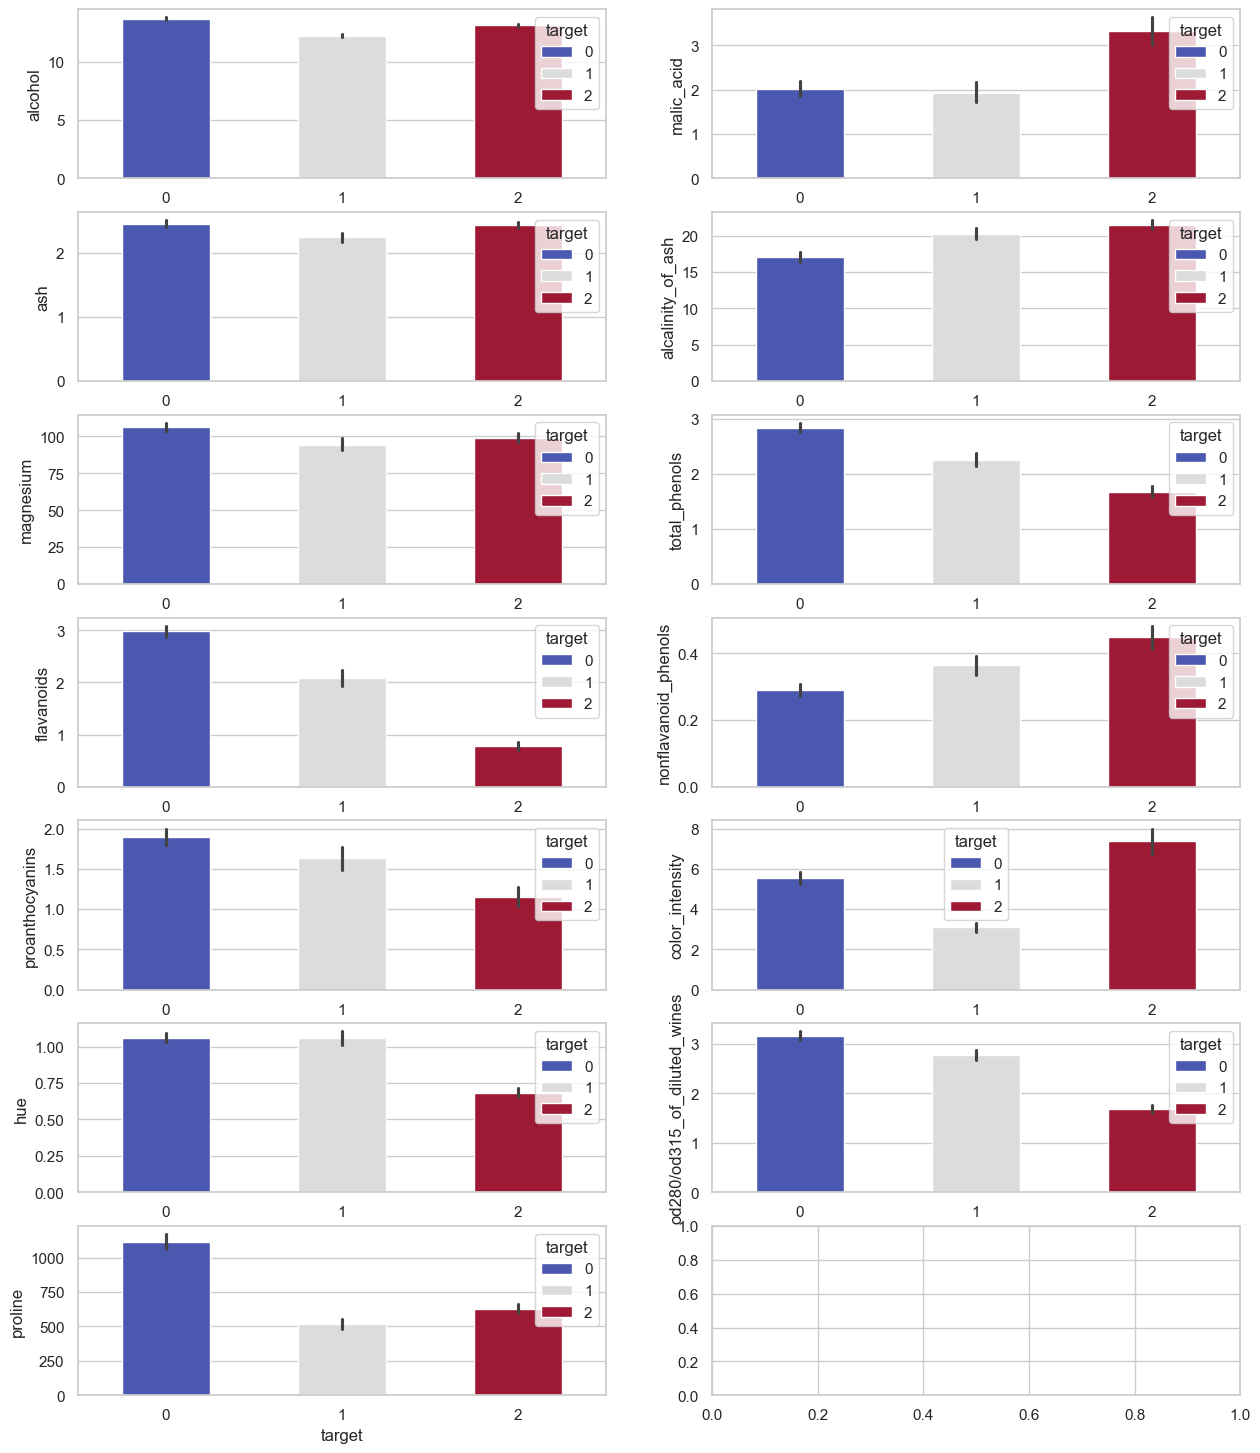

In [4]:
fig , ax = plt.subplots( 7,2, figsize = ( 15, 18 ) )
ax= ax.flatten()
for idx , val in enumerate(cols ):
    sns.barplot( data = df , x= 'target', y = val, hue ='target', ax = ax[idx] , estimator= 'mean', palette = 'coolwarm' , width= 0.5 )
plt.show()


<Figure size 1800x1400 with 0 Axes>

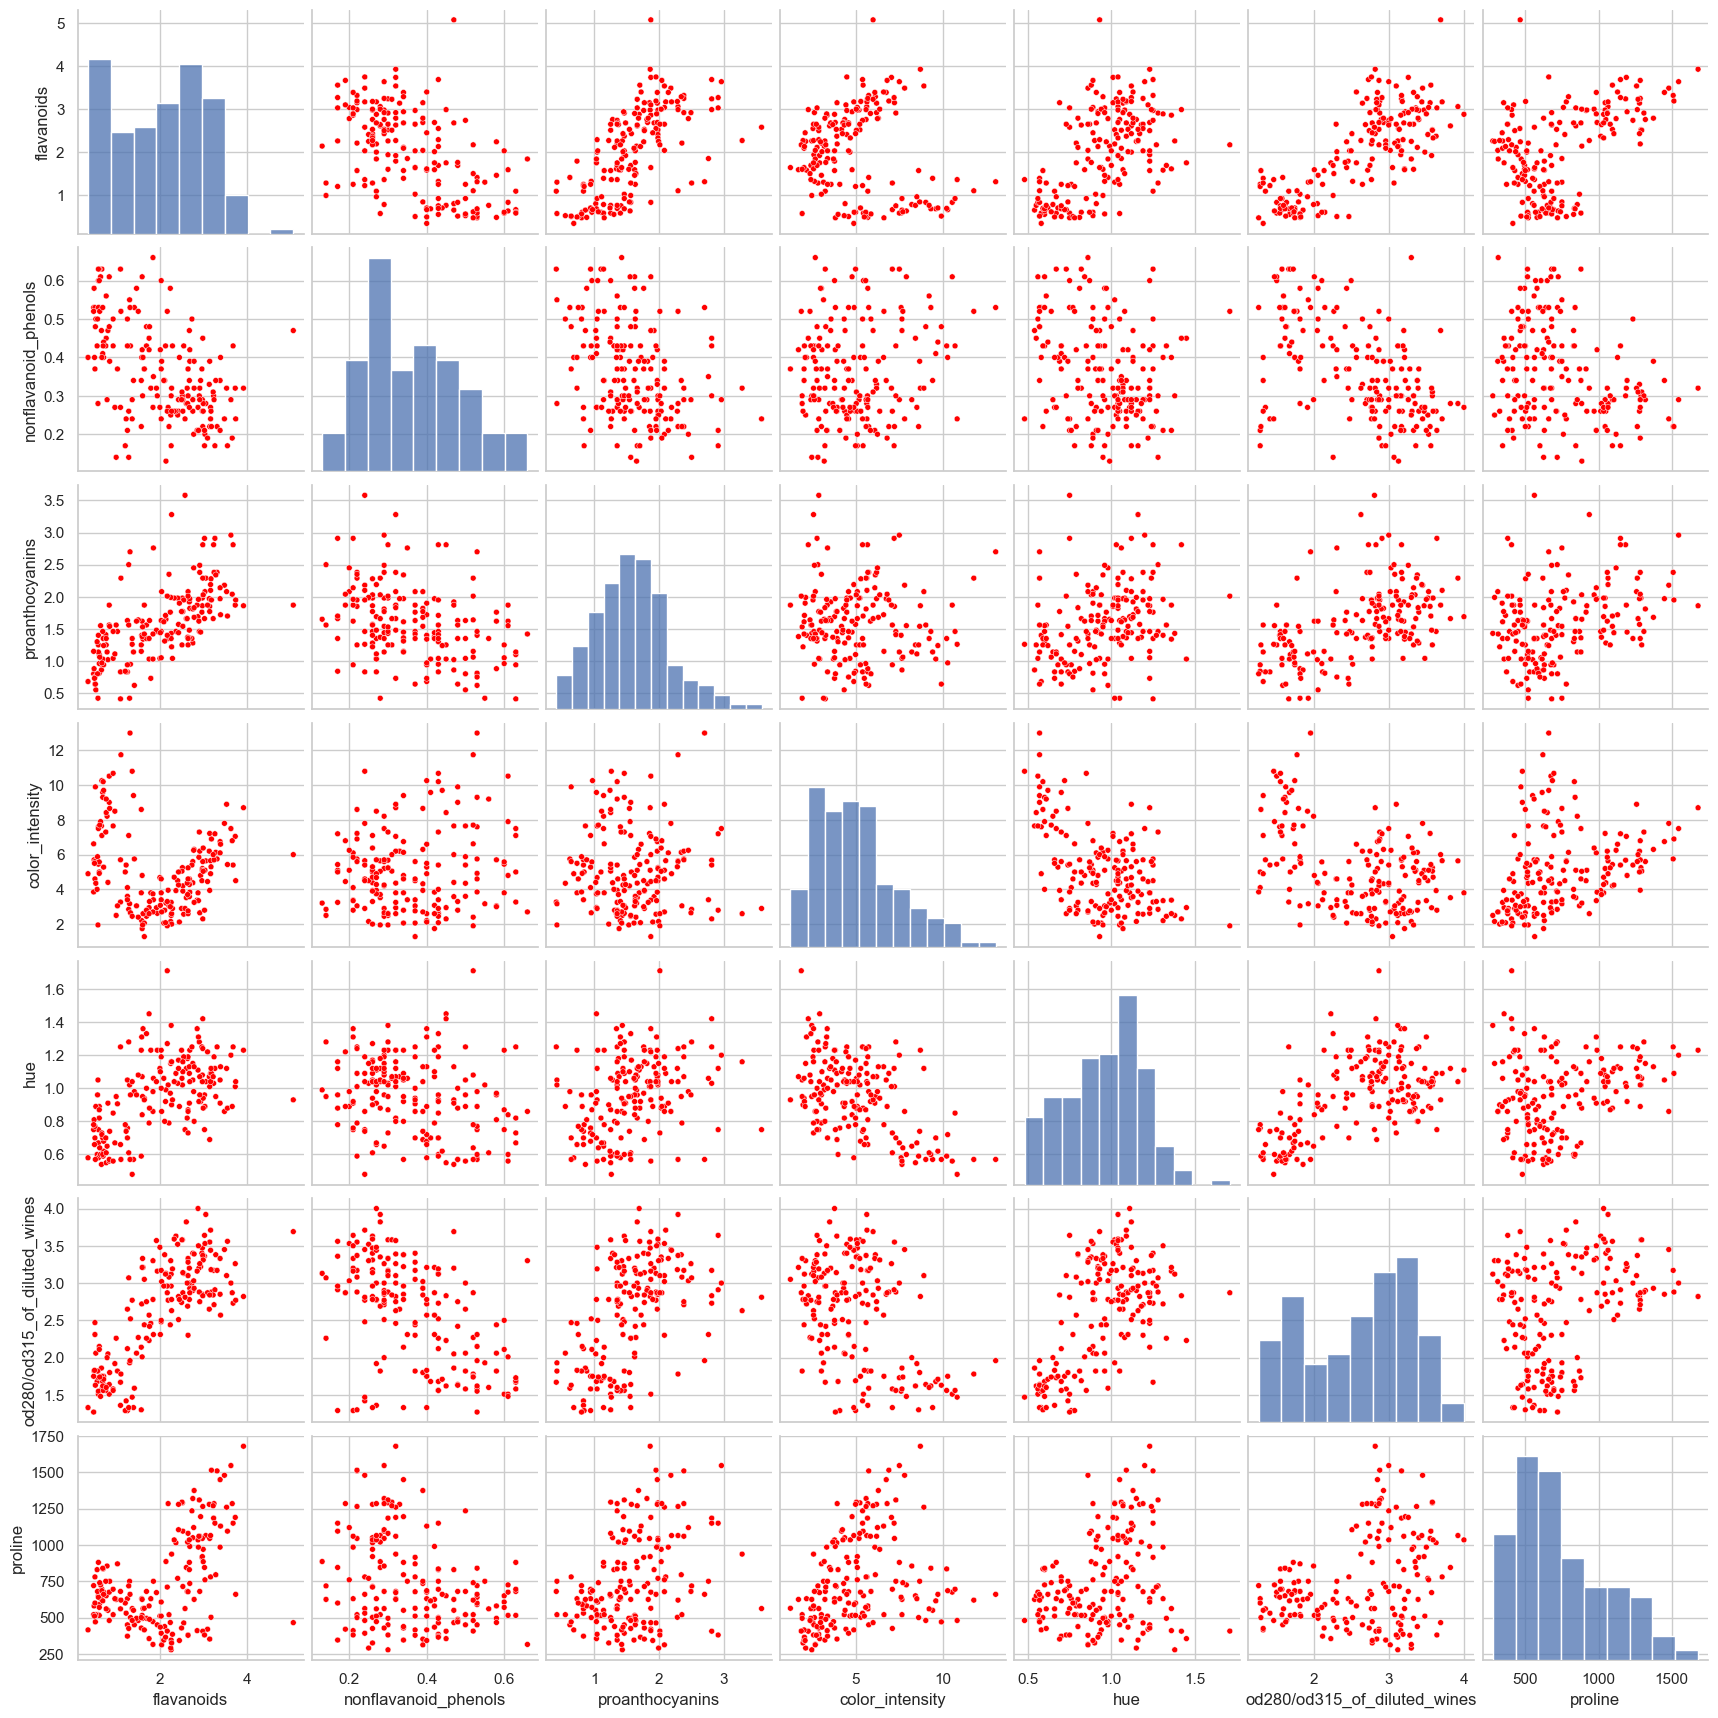

In [5]:
plt.figure( figsize = (18,14 ))  
sns.pairplot( df[cols[len(cols)//2: ] ] , plot_kws = {'color' : 'red' , 'size' : 50}   )
plt.show()

<Figure size 1800x1400 with 0 Axes>

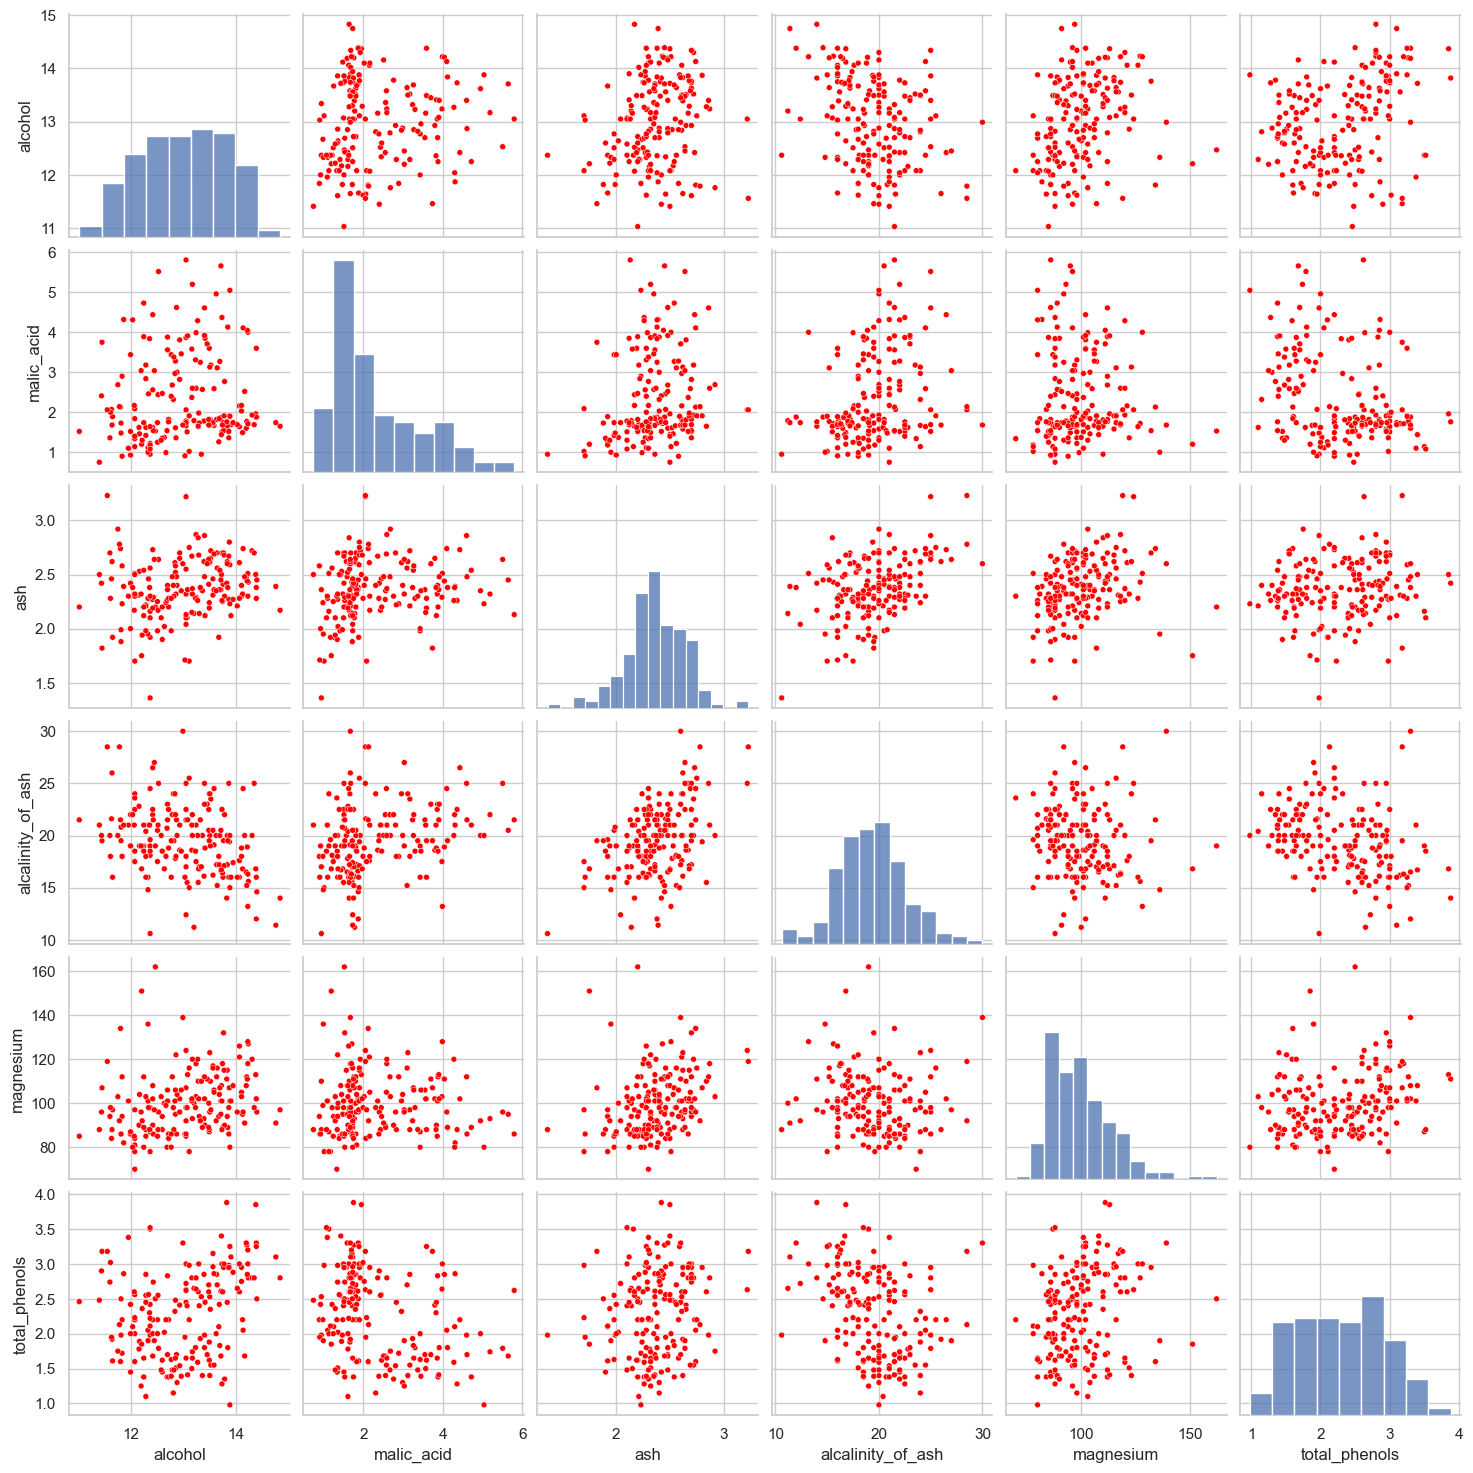

In [6]:
plt.figure( figsize = (18,14 ))  
sns.pairplot( df[cols[: len(cols)//2] ] , plot_kws = {'color' : 'red' , 'size' : 50}   )
plt.show()

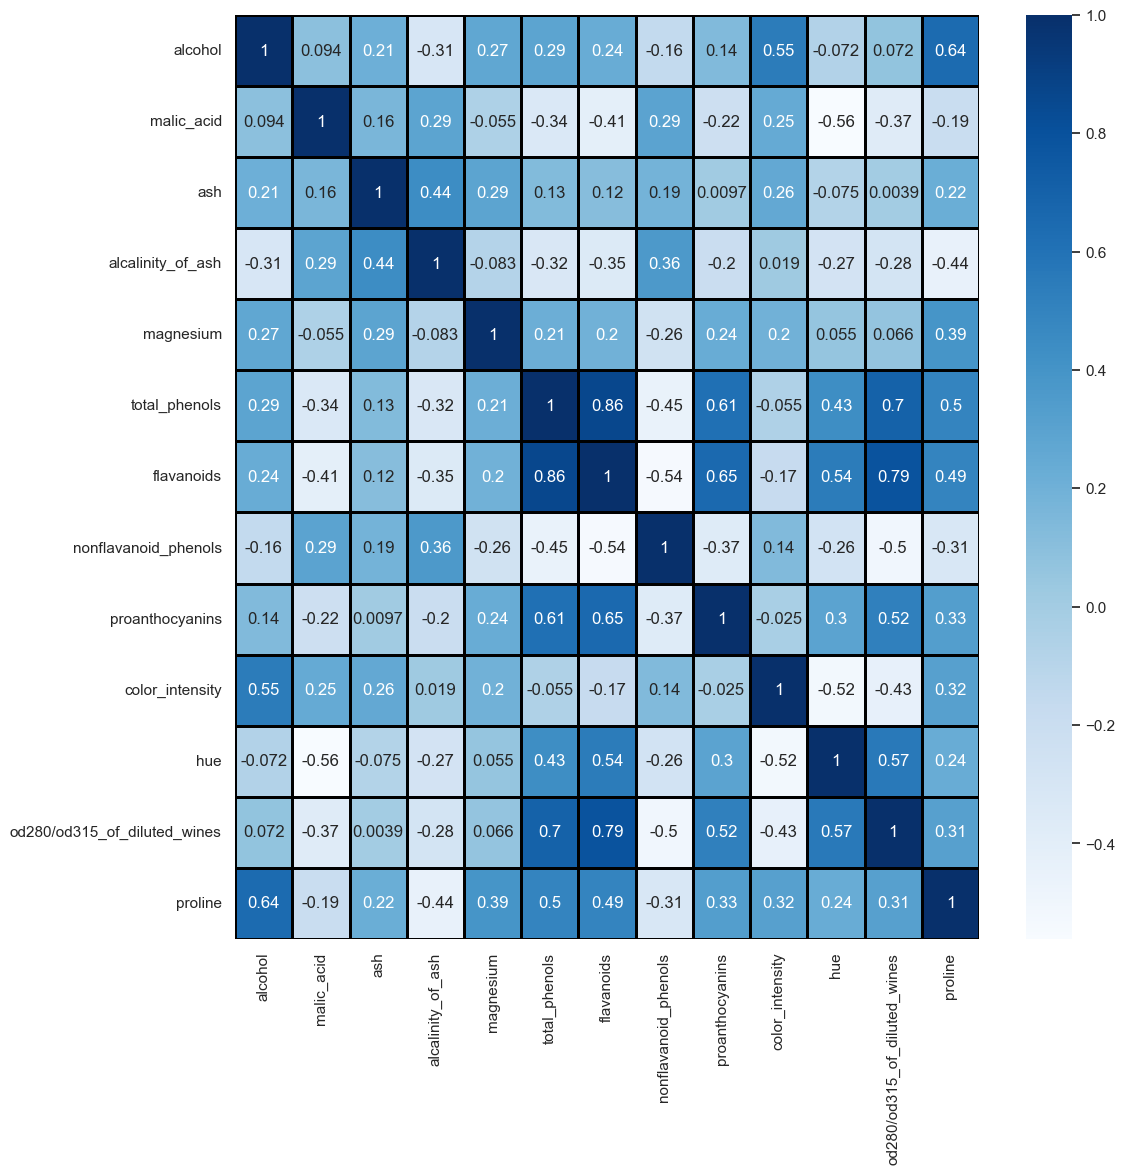

In [7]:
cols = df.drop('target', axis = 1).columns
corr = df[cols].corr()

plt.figure(figsize = ( 12,12))
sns.heatmap( corr, annot = True, cmap = 'Blues' , linecolor= 'black' , annot_kws= {'size' :12 } ,linewidths = 1 )
plt.show()



In [8]:
X = df.drop ( 'target' ,axis = 1 ) 
y=  df['target']
X_train, X_test, y_train, y_test = train_test_split ( X, y , test_size = 0.2 , shuffle = True , stratify=y ,random_state = 26) 
skfolds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 26) 
pipeline = Pipeline( [
    ('scaling' , StandardScaler() ),
    ('model' , LogisticRegression(max_iter = 1000) )
])



In [9]:
param_grid = [
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__multi_class': ['ovr', 'multinomial'],
        'model__C': [0.1, 0.2, 0.9, 5, 10],
        'model__solver': ['lbfgs', 'saga']
    },
    {
        'model': [OneVsOneClassifier(LogisticRegression(max_iter=1000))],
        'model__estimator__C': [0.1, 0.2, 0.9, 5, 10]
    }
]

grid_search = GridSearchCV(pipeline, param_grid, cv=skfolds, scoring='f1_macro')
grid_search.fit(X_train, y_train)
warnings.filterwarnings('ignore')
print("Best params:", grid_search.best_params_)
print("Best CV F1-macro:", grid_search.best_score_)

C:\Users\hp\miniconda3\envs\pydata-book\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hp\miniconda3\envs\pydata-book\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hp\miniconda3\envs\pydata-book\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hp\miniconda3\envs\pydata-book\lib\site-packages\sklear

Best params: {'model': LogisticRegression(max_iter=1000), 'model__C': 0.1, 'model__multi_class': 'ovr', 'model__solver': 'lbfgs'}
Best CV F1-macro: 0.9929038281979459


C:\Users\hp\miniconda3\envs\pydata-book\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


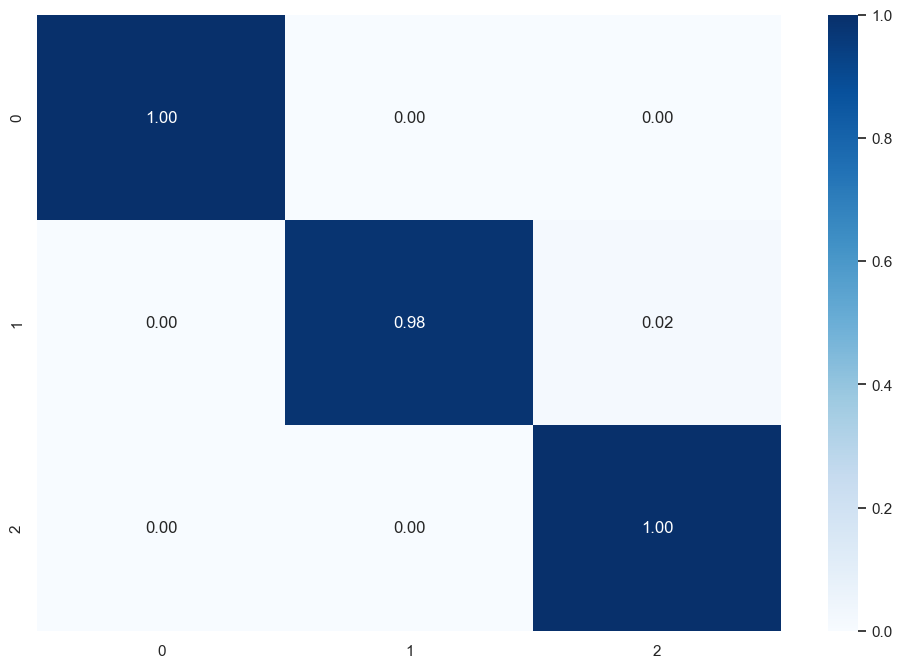

In [10]:
model  = grid_search.best_estimator_
y_train_pred = cross_val_predict(model ,X_train ,y_train ,cv = skfolds)
cm = confusion_matrix( y_train ,y_train_pred, normalize = 'true')
plt.figure( figsize = (12,8))
sns.heatmap( cm, cmap ='Blues', annot = True , fmt= '.2f')
plt.show()

In [11]:
data =classification_report(y_train ,y_train_pred ,target_names = ['class_0' ,'class_1', 'class_2'] ,output_dict = True)
df2 = pd.DataFrame( data )
df2.transpose()

,precision,recall,f1-score,support
class_0,1.000000,1.000000,1.000000,47.000000
class_1,1.000000,0.982456,0.991150,57.000000
class_2,0.974359,1.000000,0.987013,38.000000
accuracy,0.992958,0.992958,0.992958,0.992958
macro avg,0.991453,0.994152,0.992721,142.000000
weighted avg,0.993138,0.992958,0.992972,142.000000


macro_avg average the score treating each class as equally , 

the weighted average divides scores x samplesnumber / total samples in the dataset

support is appearance of samples in the dataset

In [12]:
df['Model Predicition'] = model.predict(X)
df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,Model Predicition
44,13.05,1.77,2.10,17.0,107.0,3.00,3.00,0.28,2.03,5.04,0.88,3.35,885.0,0,0
165,13.73,4.36,2.26,22.5,88.0,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520.0,2,2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.20,0.61,1.60,560.0,2,2
49,13.94,1.73,2.27,17.4,108.0,2.88,3.54,0.32,2.08,8.90,1.12,3.10,1260.0,0,0
150,13.50,3.12,2.62,24.0,123.0,1.40,1.57,0.22,1.25,8.60,0.59,1.30,500.0,2,2


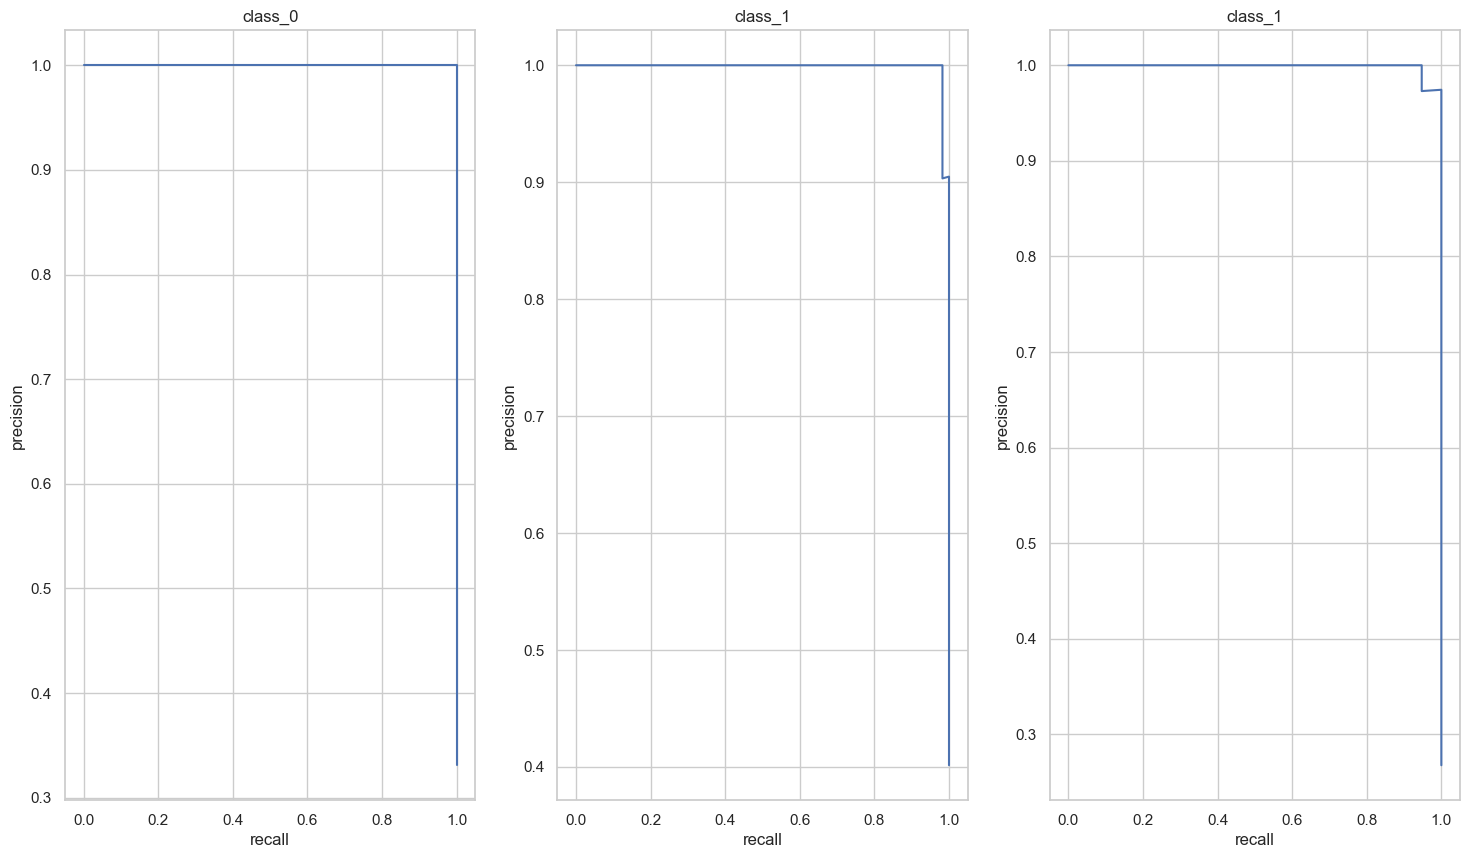

In [13]:
classes= ['class_0', 'class_1' ,'class_1' ]
fig ,ax = plt.subplots(1,3 ,figsize =(18,10))
for i,v in enumerate(classes):
    y_train_proba = cross_val_predict(model, X_train,y_train,cv=skfolds,method ='predict_proba')[:,i]
    p,r,thr = precision_recall_curve(y_train, y_train_proba, pos_label = i )
    ax[i].plot(r ,p )
    ax[i].grid(True)
    ax[i].set_title(v)
    ax[i].set_xlabel('recall')
    ax[i].set_ylabel('precision')
plt.show()

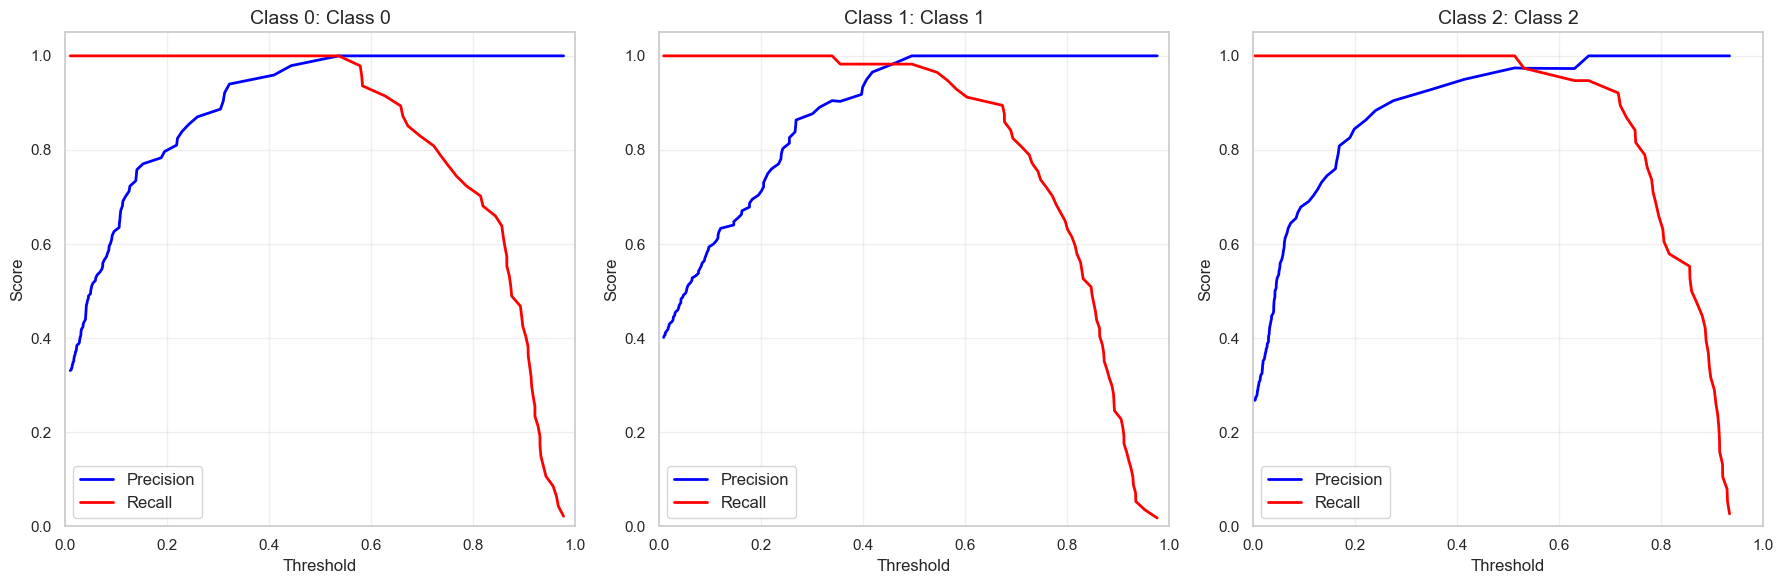

In [14]:
classes = ['Class 0', 'Class 1', 'Class 2']
y_train_proba = cross_val_predict(
    model, 
    X_train, 
    y_train, 
    cv=skfolds, 
    method='predict_proba'
)
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, class_name in enumerate(classes):
    y_proba_class = y_train_proba[:, i]
    
    precision, recall, thresholds = precision_recall_curve(
        y_train, 
        y_proba_class, 
        pos_label=i
    )
    ax[i].plot(thresholds, precision[:-1], label='Precision', color='blue', linewidth=2)
    ax[i].plot(thresholds, recall[:-1], label='Recall', color='red', linewidth=2)
    ax[i].set_title(f'Class {i}: {class_name}', fontsize=14)
    ax[i].set_xlabel('Threshold', fontsize=12)
    ax[i].set_ylabel('Score', fontsize=12)
    ax[i].legend(fontsize=12)
    ax[i].grid(True, alpha=0.3)
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

NameError: name 'auc' is not defined

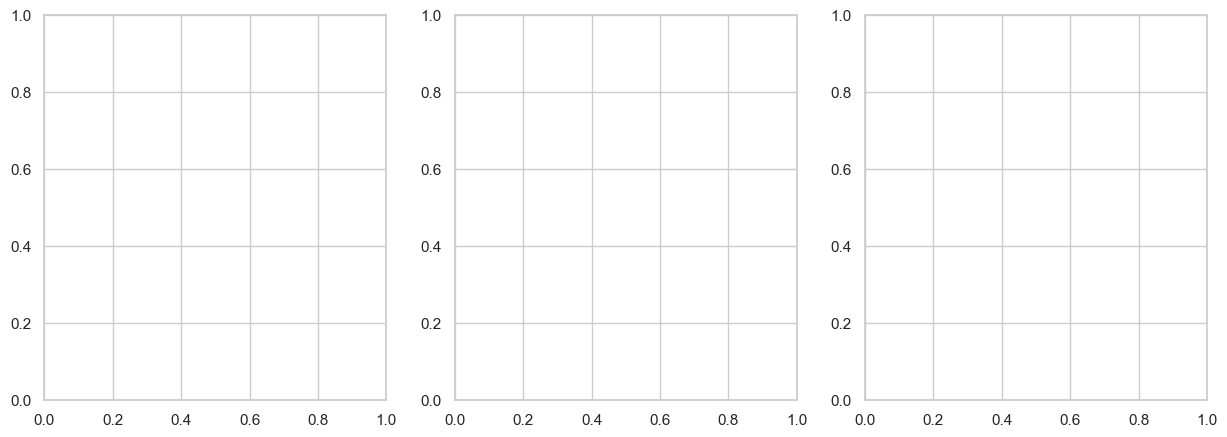

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_names = ['Class 0', 'Class 1', 'Class 2']
colors = ['blue', 'green', 'red']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=colors[i], lw=2, 
                 label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{class_names[i]} (OvR)')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()